# Mission Eagle-1 — Pilotage de l'atterrisseur lunaire

**Entreprise :** AstroDynamics  
**Rôle :** Ingénieur Machine Learning — Spécialiste RL  
**Environnement :** `LunarLander-v3` (Gymnasium)  
**Objectif :** Entraîner un agent capable d'atterrir en douceur entre les deux drapeaux avec une récompense moyenne ≥ 200 sur 100 épisodes.


---
# Preambule: Instalation et Configuration

## [Cellule] Installation des dépendances

Cette cellule installe les bibliothèques nécessaires et vérifie que toutes
les versions sont compatibles avant de commencer le travail. Elle doit être
exécutée **une seule fois** au démarrage de la session.

> **Note locale (JupyterLab) :** les dépendances sont gérées par `uv`.
> L'installation ci-dessous est idempotente — elle ne réinstalle que si
> une version est manquante ou incompatible.

In [1]:
# ============================================================
# CELLULE 0 — Installation et vérification des dépendances
# Exécuter une seule fois au démarrage de la session
# ============================================================

# — Détection de l'environnement d'exécution
import sys                           # informations système Python
import subprocess                    # exécution de commandes shell
from datetime import datetime        # pour ajouter date dans les noms de fichiers

# ----------------------------------------------------------
# Détection Colab / local
# ----------------------------------------------------------
try:
    import google.colab
    EN_COLAB = True
except ImportError:
    EN_COLAB = False


# ----------------------------------------------------------
# Installation des dépendances (Colab uniquement)
# ----------------------------------------------------------
if EN_COLAB:
    print("\n  Installation des dépendances Colab...")
    subprocess.run(
        ["pip", "install", "gymnasium[box2d]", "stable-baselines3",
         "tensorboard", "-q"],
        check=True
    )
    print("  Installation terminée.")
else:
    print( "  Mode local.............: Dépendances gérées par uv.")

# ----------------------------------------------------------
# Vérification des versions
# ----------------------------------------------------------
import gymnasium         as gym   # environnements de simulation RL
import stable_baselines3 as sb3   # algorithmes PPO, DQN, A2C
import torch                      # backend deep learning
import numpy             as np    # calcul vectoriel
import matplotlib.pyplot as plt   # visualisation

# — Bibliothèques standard
import numpy             as np    # calcul vectoriel
import matplotlib        as mpl   # configuration globale
import matplotlib.pyplot as plt   # tracé des figures

# — Formes géométriques pour le schéma
import matplotlib.patches as mpatches  # boîtes, flèches, polygones


# — Environnement de simulation
import gymnasium as gym                # API Gymnasium 1.3+



# — Gestion des chemins (détection Colab / local)
from pathlib import Path               # chemins portables

# ----------------------------------------------------------
# Configuration des chemins projet
# ----------------------------------------------------------
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    BASE   = Path('/content/drive/MyDrive/OpenClassrooms/m11_ocr')
except ImportError:
    BASE   = Path().resolve().parent   # notebooks/ → m11_ocr/

CORE       = BASE / 'core'             # env_utils, metrics, viz_utils
MODELS     = BASE / 'models'           # modèles sauvegardés
LOGS_DIR   = BASE / 'logs'             # modèles sauvegardés

MODELS.mkdir(exist_ok=True)            # création si absent

ts       = datetime.now().strftime("%y%m%d_%H%M%S")   # 250619_143022

# Ajout du dossier core au path pour les imports
import sys
if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))


# ----------------------------------------------------------
# Import des modules core du projet
# ----------------------------------------------------------
from env_utils import make_env, inspect_env, run_n_random_episodes
from metrics   import compute_stats, print_stats, moving_average, success_rate
from viz_utils import plot_episode_metrics, plot_reward_distribution

print(f"  DATE...................: {ts}")
print( "  Modules core...........: ✓ chargés")

  Mode local.............: Dépendances gérées par uv.
  DATE...................: 260623_101350
  Modules core...........: ✓ chargés


## [Cellule] Vérification des dépendances et de l'environnement

In [2]:
# ----------------------------------------------------------
# Vérification que LunarLander-v3 est disponible
# ----------------------------------------------------------

print("\n============================================================")
print("VÉRIFICATION DE L'ENVIRONNEMENT")
print("============================================================")
print(f"  Environnement...........: {'Google Colab' if EN_COLAB else 'Local JupyterLab'}")
print(f"  Python..................: {sys.version.split()[0]}")


print("\n============================================================")
print("VERSIONS DES BIBLIOTHÈQUES")
print("============================================================")
print(f"  Gymnasium...............: {gym.__version__}")
print(f"  Stable-Baselines3.......: {sb3.__version__}")
print(f"  PyTorch.................: {torch.__version__}")
print(f"  NumPy...................: {np.__version__}")
print(f"  GPU disponible..........: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU.....................: {torch.cuda.get_device_name(0)}")
else:
    print("  GPU.....................: Non — entraînement sur CPU")
    print("  Temps estimé PPO........: 25-35 min (500k steps, CPU)")

print("\n============================================================")
print("VÉRIFICATION LUNARLANDER-V3")
print("============================================================")
try:
    _env_test = gym.make("LunarLander-v3")
    _env_test.close()
    print("  LunarLander-v3..........: ✓ disponible")
except Exception as e:
    print(f"  LunarLander-v3..........: ✗ ERREUR — {e}")
    print("  Solution : pip install gymnasium[box2d]")

print("\n============================================================")
print("CONFIGURATION DES CHEMINS")
print("============================================================")
print(f"  BASE...................: {BASE}")
print(f"  CORE...................: {CORE}")
print(f"  MODELS.................: {MODELS}")



VÉRIFICATION DE L'ENVIRONNEMENT
  Environnement...........: Local JupyterLab
  Python..................: 3.12.12

VERSIONS DES BIBLIOTHÈQUES
  Gymnasium...............: 1.3.0
  Stable-Baselines3.......: 2.9.0
  PyTorch.................: 2.12.0+cpu
  NumPy...................: 2.4.6
  GPU disponible..........: False
  GPU.....................: Non — entraînement sur CPU
  Temps estimé PPO........: 25-35 min (500k steps, CPU)

VÉRIFICATION LUNARLANDER-V3
  LunarLander-v3..........: ✓ disponible

CONFIGURATION DES CHEMINS
  BASE...................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr
  CORE...................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\core
  MODELS.................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models


---
# Étape 1 - Explorez l'environnement et établissez une base de référence

## [Cellule] Exploration de l'environnement LunarLander-v3

Avant tout entraînement, il est indispensable de comprendre les **espaces
d'observation et d'action** de notre environnement.

In [3]:
# ============================================================
# 1. Création et inspection de l'environnement
# ============================================================
env = make_env("LunarLander-v3", render_mode="rgb_array", seed=42)
obs, info = env.reset(seed=42)

inspect_env(env)

print("\n============================================================")
print("ESPACE D'OBSERVATION — Box(8,)")
print("============================================================")
print(f"  Type.....................: {type(env.observation_space).__name__}")
print(f"  Shape....................: {env.observation_space.shape}")
print(f"  dtype....................: {env.observation_space.dtype}")

# Noms des 8 variables d'observation
NOMS_OBS = [
    "x   position horizontale",
    "y   position verticale  ",
    "ẋ   vitesse horizontale ",
    "ẏ   vitesse verticale   ",
    "θ   angle inclinaison   ",
    "θ̇   vitesse angulaire   ",
    "c_g contact pied gauche ",
    "c_d contact pied droit  ",
]
TYPES_OBS = [
    "continu  [−∞, +∞] m",
    "continu  [−∞, +∞] m",
    "continu  [−∞, +∞] m/s",
    "continu  [−∞, +∞] m/s",
    "continu  [−π, +π] rad",
    "continu  [−∞, +∞] rad/s",
    "booléen  {0, 1}",
    "booléen  {0, 1}",
]

print()
print(f"  {'idx':<5} {'Variable':<28} {'Type':<25} {'Valeur initiale':>15}")
print(f"  {'─'*5} {'─'*28} {'─'*25} {'─'*15}")
for i, (nom, typ, val) in enumerate(zip(NOMS_OBS, TYPES_OBS, obs)):
    marqueur = " ★" if i >= 6 else "  "
    print(f"  [{i}]{marqueur} {nom}  {typ:<25} {val:>+15.6f}")
print("\n  ★ = booléen (les 6 autres sont continues float32)")

print("\n============================================================")
print("ESPACE D'ACTION — Discrete(4)")
print("============================================================")
NOMS_ACTIONS = [
    "Do nothing       — aucun moteur actif",
    "Moteur gauche    — pousse vers la droite",
    "Moteur principal — pousse vers le haut",
    "Moteur droit     — pousse vers la gauche",
]
print(f"  Nombre d'actions.........: {env.action_space.n}")
print()
for i, nom in enumerate(NOMS_ACTIONS):
    marqueur = " ←" if i == 2 else "  "
    print(f"  Action {i}{marqueur}  {nom}")

print("\n============================================================")
print("PARAMÈTRES DE RÉCOMPENSE")
print("============================================================")
print("  Pendant le vol...........  + proportionnel (distance, vitesse, angle)")
print("  Bonus atterrissage zone..  + 100  (final)")
print("  Contact pied gauche......  +  10  (final)")
print("  Contact pied droit.......  +  10  (final)")
print("  Tir moteur principal.....  −   0.30 / pas")
print("  Tir moteur latéral.......  −   0.03 / pas")
print("  Crash / hors zone........  − 100  (fin épisode)")
print("  ─────────────────────────────────────────────")
print("  Objectif.................:  moyenne ≥ 200 sur 100 épisodes")

env.close()


RAPPORT D INSPECTION DE L ENVIRONNEMENT

-- ESPACE D OBSERVATION -------------------------
  Type................: Box
  Shape...............: (8,)
  dtype...............: float32
  Borne inferieure....: [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
  Borne superieure....: [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]
  Exemple aleatoire...: [-1.9868237  -0.21016093  2.0074437  -5.6816726   4.7647      3.1120708
  0.02396452  0.9776681 ]

-- ESPACE D ACTION --------------------------------
  Type................: Discrete
  N actions...........: 4
  Actions dispo.......: [0, 1, 2, 3]
  Exemple aleatoire...: 2

ESPACE D'OBSERVATION — Box(8,)
  Type.....................: Box
  Shape....................: (8,)
  dtype....................: float32

  idx   Variable                     Type                      Valeur initiale
  ───── ──────────────────────────── ───────────────────────── ───────────────
  [0

<img src="../docs/images/LunarLander_V3_Environement.png" width="900"/>

## [Cellule] Visualisation l'environnement

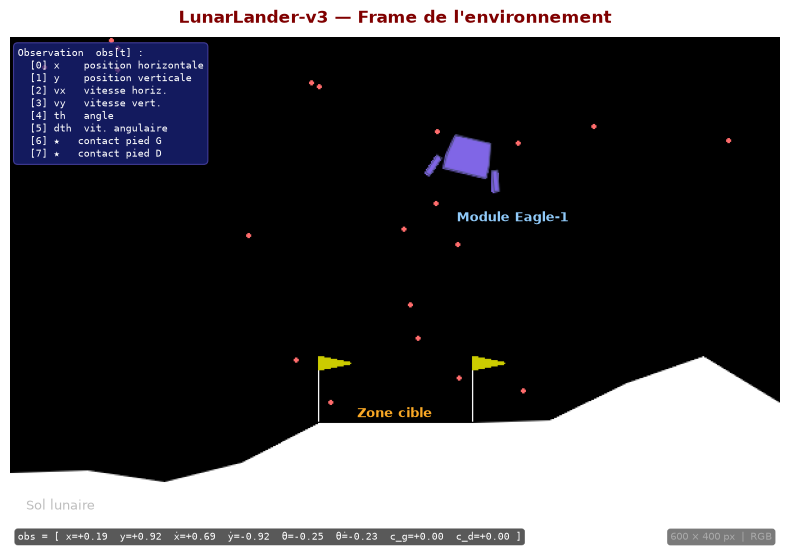


  Frame sauvegardée.......: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\mission_260623_101350_lunarlander_frame.png


In [4]:
# ============================================================
# 2. Visualisation — frame initiale de l'environnement
# ============================================================
import matplotlib.pyplot       as plt
import matplotlib.patches      as mpatches
import numpy                   as np
import gymnasium               as gym

from env_utils import make_env

# ----------------------------------------------------------
# Capture d'une frame aléatoire après quelques pas
# ----------------------------------------------------------
env_viz = make_env("LunarLander-v3", render_mode="rgb_array", seed=0)
obs, _  = env_viz.reset(seed=0)

# Quelques pas aléatoires pour avoir une position intéressante
# (évite le frame initial trop statique, lander toujours centré)
for _ in range(30):
    action            = env_viz.action_space.sample()
    obs, _, term, trunc, _ = env_viz.step(action)
    if term or trunc:
        obs, _ = env_viz.reset(seed=0)
        break

frame = env_viz.render()   # numpy array (H, W, 3) RGB
env_viz.close()

# ----------------------------------------------------------
# Figure avec annotations
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(frame)
ax.set_title(
    "LunarLander-v3 — Frame de l'environnement",
    fontsize=12, fontweight="bold", color="#800000", pad=10
)

# Dimensions de la frame
H, W, _ = frame.shape

# ── Annotations textuelles sans flèches ───────────────────

# Module Eagle-1 — positionné depuis obs
x_norm    = (obs[0] + 1.5) / 3.0
y_norm    = 1.0 - (obs[1] / 1.5)
px_lander = x_norm * W
py_lander = y_norm * H

ax.text(
    px_lander + 10, py_lander - 10,
    "Module Eagle-1",
    fontsize=9, color="#90CAF9", fontweight="bold"
)

ax.text(
    W * 0.45, H * 0.74,
    "Zone cible",
    fontsize=9, color="#F9A825", fontweight="bold"
)

ax.text(
    W * 0.02, H * 0.92,
    "Sol lunaire",
    fontsize=9, color="#BDBDBD"
)

# ── Légende des observations dans un encadré ──────────────
legende = (
    "Observation  obs[t] :\n"
    "  [0] x    position horizontale\n"
    "  [1] y    position verticale\n"
    "  [2] vx   vitesse horiz.\n"
    "  [3] vy   vitesse vert.\n"
    "  [4] th   angle\n"
    "  [5] dth  vit. angulaire\n"
    "  [6] ★   contact pied G\n"
    "  [7] ★   contact pied D"
)
ax.text(
    0.01, 0.98, legende,
    transform=ax.transAxes,
    fontsize=7.5, color="white",
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#1A237E", alpha=0.75,
        edgecolor="#534AB7", linewidth=0.8
    )
)

# ── Valeurs courantes de obs ───────────────────────────────
NOMS_COURTS = ["x", "y", "ẋ", "ẏ", "θ", "θ̇", "c_g", "c_d"]
valeurs_txt = "  ".join(
    f"{n}={v:+.2f}" for n, v in zip(NOMS_COURTS, obs)
)
ax.text(
    0.01, 0.02, f"obs = [ {valeurs_txt} ]",
    transform=ax.transAxes,
    fontsize=7, color="white",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#212121", alpha=0.75,
        edgecolor="#555555", linewidth=0.5
    )
)

# ── Dimensions de la frame ─────────────────────────────────
ax.text(
    0.99, 0.02,
    f"{W} × {H} px  |  RGB",
    transform=ax.transAxes,
    fontsize=7.5, color="#AAAAAA",
    ha="right",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#212121", alpha=0.6,
        edgecolor="none"
    )
)

ax.axis("off")
plt.tight_layout()

fig_path = MODELS / f"mission_{ts}_lunarlander_frame.png"

plt.savefig(fig_path,
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
print(f"\n  Frame sauvegardée.......: {fig_path}")

---
## Point 1. Baseline avec Politique aléatoire 

Avant d'entraîner quoi que ce soit, il est indispensable d'établir une
**référence de performance** avec un agent aléatoire.

Cette baseline répond à une question clé : **à quel point notre agent
entraîné s'améliore-t-il par rapport au hasard pur ?**

La documentation OpenClassrooms exige **au minimum 50 épisodes** pour
l'évaluation de base — nous en utilisons 100 pour avoir une mesure
statistiquement fiable dès le départ.

**Ce que l'on attend**

Un agent aléatoire sur LunarLander-v3 obtient typiquement :
- **Récompense moyenne : −100 à −200** (crashes fréquents)
- **Taux de réussite : 0 à 2 %** (atterrissages accidentels)

Ce chiffre servira de **point zéro** pour mesurer la progression de
l'agent PPO ensuite.

### [Cellule] Baseline 100 épisodes


POLITIQUE ALÉATOIRE — BASELINE
  Épisodes................: 100
  Stratégie...............: action aléatoire (env.action_space.sample())
  Seuil de succès.........: récompense ≥ 200
  Épisode  20............: moy. partielle = -135.6
  Épisode  40............: moy. partielle = -163.5
  Épisode  60............: moy. partielle = -173.1
  Épisode  80............: moy. partielle = -186.3
  Épisode 100............: moy. partielle = -190.4

RÉSULTATS BASELINE — POLITIQUE ALÉATOIRE
  Récompense moyenne......: -190.39
  Écart-type..............: 118.29
  Récompense minimale.....: -534.99
  Récompense maximale.....: +26.93
  Durée moyenne (pas).....: 90.4
  Épisodes réussis........: 0 / 100
  Taux de succès..........: 0.0 %
  ─────────────────────────────────────────────
  Objectif PPO............: ≥ 200 (écart : +390 pts à combler)


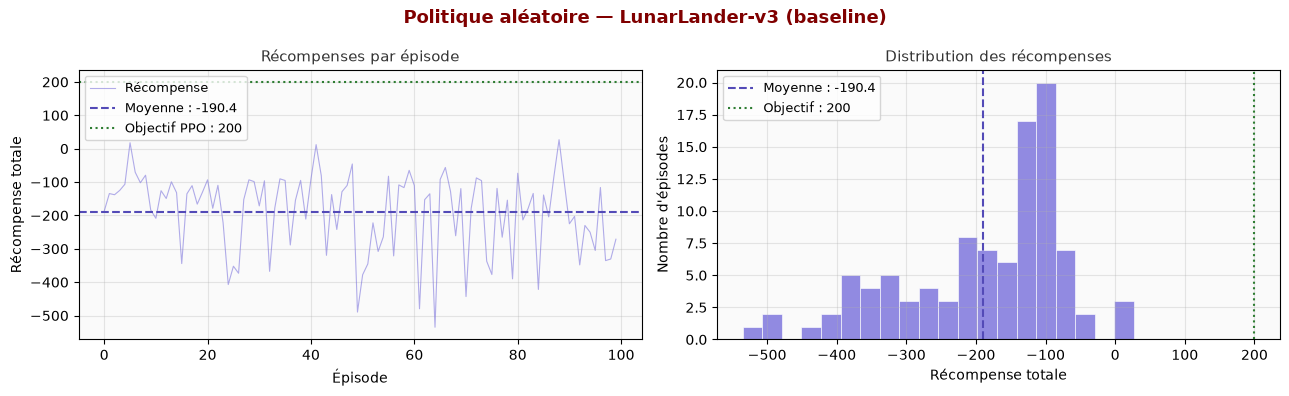


  Graphique sauvegardé....: baseline_aleatoire.png


In [5]:
# ============================================================
# CELLULE 2 — Politique aléatoire : 
# ============================================================

# — Bibliothèques standard
import numpy             as np    # calcul vectoriel
import matplotlib.pyplot as plt   # tracé des résultats

# — Environnement
import gymnasium as gym           # API Gymnasium 1.3+

# — Modules core
from env_utils import make_env
from metrics   import compute_stats, print_stats, moving_average

# ----------------------------------------------------------
# Paramètres de la baseline
# ----------------------------------------------------------
N_EPISODES_BASELINE = 100         # épisodes d'évaluation aléatoire
SEED_BASELINE       = 42          # reproductibilité
SEUIL_SUCCES        = 200         # récompense minimale = succès

print("\n============================================================")
print("POLITIQUE ALÉATOIRE — BASELINE")
print("============================================================")
print(f"  Épisodes................: {N_EPISODES_BASELINE}")
print(f"  Stratégie...............: action aléatoire (env.action_space.sample())")
print(f"  Seuil de succès.........: récompense ≥ {SEUIL_SUCCES}")

# ----------------------------------------------------------
# Boucle d'évaluation aléatoire
# ----------------------------------------------------------
env_baseline = make_env(
    "LunarLander-v3",
    render_mode=None,
    seed=SEED_BASELINE
)

rewards_baseline = []             # récompense totale par épisode
longueurs        = []             # nombre de pas par épisode
n_succes         = 0              # compteur d'atterrissages réussis

for episode in range(N_EPISODES_BASELINE):

    obs, info    = env_baseline.reset(seed=SEED_BASELINE + episode)
    total_reward = 0.0
    n_pas        = 0
    terminated   = False
    truncated    = False

    while not (terminated or truncated):
        # Action purement aléatoire — aucune politique
        action                              = env_baseline.action_space.sample()
        obs, reward, terminated, truncated, info = env_baseline.step(action)
        total_reward += reward
        n_pas        += 1

    rewards_baseline.append(total_reward)
    longueurs.append(n_pas)
    if total_reward >= SEUIL_SUCCES:
        n_succes += 1

    # Progression tous les 20 épisodes
    if (episode + 1) % 20 == 0:
        moy_partielle = np.mean(rewards_baseline)
        print(f"  Épisode {episode + 1:>3}............: "
              f"moy. partielle = {moy_partielle:+.1f}")

env_baseline.close()

# ----------------------------------------------------------
# Statistiques de la baseline
# ----------------------------------------------------------
rewards_arr = np.array(rewards_baseline)

moy_baseline  = np.mean(rewards_arr)    # récompense moyenne
std_baseline  = np.std(rewards_arr)     # écart-type
min_baseline  = np.min(rewards_arr)     # pire épisode
max_baseline  = np.max(rewards_arr)     # meilleur épisode
moy_longueur  = np.mean(longueurs)      # durée moyenne en pas
taux_succes   = n_succes / N_EPISODES_BASELINE * 100  # % succès

print("\n============================================================")
print("RÉSULTATS BASELINE — POLITIQUE ALÉATOIRE")
print("============================================================")
print(f"  Récompense moyenne......: {moy_baseline:+.2f}")
print(f"  Écart-type..............: {std_baseline:.2f}")
print(f"  Récompense minimale.....: {min_baseline:+.2f}")
print(f"  Récompense maximale.....: {max_baseline:+.2f}")
print(f"  Durée moyenne (pas).....: {moy_longueur:.1f}")
print(f"  Épisodes réussis........: {n_succes} / {N_EPISODES_BASELINE}")
print(f"  Taux de succès..........: {taux_succes:.1f} %")
print(f"  ─────────────────────────────────────────────")
print(f"  Objectif PPO............: ≥ {SEUIL_SUCCES:.0f} (écart : "
      f"{SEUIL_SUCCES - moy_baseline:+.0f} pts à combler)")

# ----------------------------------------------------------
# Visualisation : distribution des récompenses
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "Politique aléatoire — LunarLander-v3 (baseline)",
    fontsize=13, fontweight="bold", color="#800000"
)

# Panneau gauche : récompenses par épisode
axes[0].plot(rewards_arr, color="#7F77DD",
             linewidth=0.8, alpha=0.6, label="Récompense")
axes[0].axhline(moy_baseline, color="#534AB7",
                linewidth=1.5, linestyle="--",
                label=f"Moyenne : {moy_baseline:+.1f}")
axes[0].axhline(SEUIL_SUCCES, color="#2E7D32",
                linewidth=1.5, linestyle=":",
                label=f"Objectif PPO : {SEUIL_SUCCES}")
axes[0].set_xlabel("Épisode")
axes[0].set_ylabel("Récompense totale")
axes[0].set_title("Récompenses par épisode",
                  fontsize=11, color="#333333")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor("#FAFAFA")

# Panneau droit : histogramme de distribution
axes[1].hist(rewards_arr, bins=20,
             color="#7F77DD", edgecolor="white",
             alpha=0.85, linewidth=0.5)
axes[1].axvline(moy_baseline, color="#534AB7",
                linewidth=1.5, linestyle="--",
                label=f"Moyenne : {moy_baseline:+.1f}")
axes[1].axvline(SEUIL_SUCCES, color="#2E7D32",
                linewidth=1.5, linestyle=":",
                label=f"Objectif : {SEUIL_SUCCES}")
axes[1].set_xlabel("Récompense totale")
axes[1].set_ylabel("Nombre d'épisodes")
axes[1].set_title("Distribution des récompenses",
                  fontsize=11, color="#333333")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor("#FAFAFA")

# Sauvegarde AVANT plt.show()
plt.tight_layout()

plt_path = MODELS / f"mission_{ts}_baseline_aleatoire.png" 
plt.savefig(plt_path,
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\n  Graphique sauvegardé....: baseline_aleatoire.png")

### Interprétation de la baseline

Les résultats confirment que la politique aléatoire est **totalement
inefficace** sur LunarLander-v3. Avec une moyenne de **−193.6 pts**
et **0 % de succès** sur 100 épisodes, le module crashe ou sort de
zone quasi-systématiquement — exactement ce qui était attendu.

L'écart-type élevé (105 pts) révèle un comportement **très instable** :
certains épisodes atteignent −35 pts (vol court sans crash immédiat),
d'autres descendent jusqu'à −474 pts (crash brutal après de nombreux
pas chaotiques). La durée moyenne de 89 pas confirme que l'agent
crashe rapidement sans jamais apprendre à maintenir une trajectoire.

**Ce chiffre est notre point zéro.** Toute amélioration de PPO sera
mesurée par rapport à cette référence.

| Métrique | Politique aléatoire | Objectif PPO |
|----------|:-------------------:|:------------:|
| Récompense moyenne | **−193.6** | **≥ +200** |
| Écart-type | 105.5 | < 50 (stable) |
| Taux de succès | **0 %** | **≥ 80 %** |
| Durée moyenne | 89 pas | ≈ 250 pas |
| Comportement | Chaotique, crashs | Descente stable, précis |


###### Point 2. Adaptez l’algorithme PPO pour les espaces de contrôle continus

## Point 2. PPO (Proximal Policy Optimization). 

### Pourquoi, choix et justification?

LunarLander-v3 expose un espace d'action **discret** (`Discrete(4)`).
DQN et PPO sont tous deux compatibles. Nous choisissons **PPO** comme
algorithme principal pour deux raisons :

1. **Stabilité** — PPO utilise un mécanisme de clipping qui empêche
   les mises à jour trop agressives de la politique, crucial quand
   la récompense est dense et variable.
2. **Généralité** — PPO fonctionne sur les espaces discrets *et*
   continus, ce qui le rend réutilisable si l'on passe à la version
   `continuous=True` de LunarLander.

DQN sera utilisé comme comparaison.

### Hyperparamètres clés de PPO

| Paramètre | Rôle | Valeur choisie |
|-----------|------|:--------------:|
| `learning_rate` | Pas de gradient de la politique | `3e-4` |
| `n_steps` | Pas collectés avant chaque mise à jour | `1024` |
| `batch_size` | Taille des mini-batchs d'optimisation | `64` |
| `n_epochs` | Passages sur les données collectées | `10` |
| `gamma` | Facteur d'actualisation des récompenses futures | `0.999` |
| `gae_lambda` | Paramètre GAE (biais/variance trade-off) | `0.98` |
| `clip_range` | Seuil de clipping PPO | `0.2` |
| `ent_coef` | Coefficient d'entropie (encourage l'exploration) | `0.01` |
| `total_timesteps` | Interactions totales avec l'environnement | `500 000` |

> **Note CPU :** `n_steps=1024` avec `batch_size=64` donne
> 16 mini-batchs par mise à jour — bon équilibre vitesse/stabilité
> sur CPU sans GPU.


### [Cellule] 🛠️ Hyperparamètres PPO 

In [6]:
# ============================================================
# Hyperparamètres PPO + tableau de configuration
# ============================================================

# — Bibliothèques standard
import numpy             as np    # calcul vectoriel
import matplotlib.pyplot as plt   # visualisation

# — Algorithme PPO de Stable-Baselines3
from stable_baselines3          import PPO          # algorithme principal
from stable_baselines3.common.env_util import make_vec_env  # env vectorisé

# — Callback pour l'early stopping et la sauvegarde
from stable_baselines3.common.callbacks import (
    EvalCallback,           # évaluation périodique + sauvegarde best model
    StopTrainingOnRewardThreshold,  # arrêt si récompense cible atteinte
)

# — Modules core
from env_utils import make_env

# — Gestion des chemins et du temps
from pathlib import Path         # chemins portables
import time                      # mesure du temps d'entraînement

# ----------------------------------------------------------
# Configuration des chemins (reprise de Cellule 1)
# ----------------------------------------------------------
try:
    import google.colab
    BASE = Path('/content/drive/MyDrive/OpenClassrooms/m11_ocr')
except ImportError:
    BASE = Path().resolve().parent

MODELS  = BASE / 'models'                # dossier de sauvegarde des modèles
MODELS.mkdir(exist_ok=True)

# dossiers pour le log TensorBoard
LOGS_PPO_TRAIN    = BASE / 'logs' / f"mission_{ts}_ppo_train"   
LOGS_PPO_EVAL     = BASE / 'logs' / f"mission_{ts}_ppo_eval"  

LOGS_DQN_TRAIN    = BASE / 'logs' / f"mission_{ts}_dqn_train"  
LOGS_DQN_EVAL     = BASE / 'logs' / f"mission_{ts}_dqn_eval"  

LOGS_PPO_TRAIN.mkdir(parents=True, exist_ok=True)
LOGS_PPO_EVAL.mkdir(parents=True,  exist_ok=True)
LOGS_DQN_TRAIN.mkdir(parents=True, exist_ok=True)
LOGS_DQN_EVAL.mkdir(parents=True,  exist_ok=True)

# ============================================================
# Hyperparamètres PPO — configuration principale
# ============================================================

# — Environnement
ENV_ID          = "LunarLander-v3" # identifiant Gymnasium
SEED            = 42               # graine pour reproductibilité

# — Durée d'entraînement
TOTAL_TIMESTEPS = 500_000          # interactions totales avec l'env

# — Architecture réseau (MlpPolicy = réseau dense)
POLICY          = "MlpPolicy"      # perceptron multicouches

# — Hyperparamètres de l'algorithme PPO
LEARNING_RATE   = 3e-4             # pas de gradient Adam
N_STEPS         = 1024             # pas collectés avant chaque update
BATCH_SIZE      = 64               # taille des mini-batchs
N_EPOCHS        = 10               # passages sur les données collectées
GAMMA           = 0.999            # facteur d'actualisation récompenses futures
GAE_LAMBDA      = 0.98             # paramètre GAE (biais/variance)
CLIP_RANGE      = 0.2              # seuil de clipping PPO
ENT_COEF        = 0.01             # coefficient d'entropie (exploration)
VF_COEF         = 0.5              # coefficient de la fonction de valeur
MAX_GRAD_NORM   = 0.5              # norme maximale du gradient (stabilité)

# — Évaluation périodique pendant l'entraînement
EVAL_FREQ       = 10_000           # évaluation tous les N pas
N_EVAL_EPISODES = 20               # épisodes par évaluation périodique
REWARD_THRESHOLD = 250             # seuil d'early stopping (marge sur 200)

# — Calculs dérivés (vérification de cohérence)
n_updates       = TOTAL_TIMESTEPS // N_STEPS  # nombre de mises à jour
n_minibatches   = N_STEPS // BATCH_SIZE        # mini-batchs par update

print("\n============================================================")
print("CONFIGURATION PPO — EAGLE-1")
print("============================================================")
print(f"  Environnement...........: {ENV_ID}")
print(f"  Algorithme..............: PPO ({POLICY})")
print(f"  Total timesteps.........: {TOTAL_TIMESTEPS:,}")
print()
print(f"  learning_rate...........: {LEARNING_RATE}")
print(f"  n_steps.................: {N_STEPS}")
print(f"  batch_size..............: {BATCH_SIZE}")
print(f"  n_epochs................: {N_EPOCHS}")
print(f"  gamma...................: {GAMMA}")
print(f"  gae_lambda..............: {GAE_LAMBDA}")
print(f"  clip_range..............: {CLIP_RANGE}")
print(f"  ent_coef................: {ENT_COEF}")
print(f"  vf_coef.................: {VF_COEF}")
print(f"  max_grad_norm...........: {MAX_GRAD_NORM}")
print()
print(f"  ── Dérivés ──────────────────────────────")
print(f"  Mises à jour totales....: {n_updates}")
print(f"  Mini-batchs / update....: {n_minibatches}")
print(f"  Seuil early stopping....: {REWARD_THRESHOLD} pts")
print(f"  Fréquence évaluation....: tous les {EVAL_FREQ:,} pas")
print()
print(f"  ── Référence baseline ───────────────────")
print(f"  Baseline aléatoire......: −193.6 pts (0 % succès)")
print(f"  Objectif final..........: ≥ +200 pts (100 épisodes)")
print(f"  Écart à combler.........: +394 pts")



CONFIGURATION PPO — EAGLE-1
  Environnement...........: LunarLander-v3
  Algorithme..............: PPO (MlpPolicy)
  Total timesteps.........: 500,000

  learning_rate...........: 0.0003
  n_steps.................: 1024
  batch_size..............: 64
  n_epochs................: 10
  gamma...................: 0.999
  gae_lambda..............: 0.98
  clip_range..............: 0.2
  ent_coef................: 0.01
  vf_coef.................: 0.5
  max_grad_norm...........: 0.5

  ── Dérivés ──────────────────────────────
  Mises à jour totales....: 488
  Mini-batchs / update....: 16
  Seuil early stopping....: 250 pts
  Fréquence évaluation....: tous les 10,000 pas

  ── Référence baseline ───────────────────
  Baseline aléatoire......: −193.6 pts (0 % succès)
  Objectif final..........: ≥ +200 pts (100 épisodes)
  Écart à combler.........: +394 pts


---
### [Cellule] 🏋️‍♀️ EntrenaimentPPO

C'est la cellule principale — elle peut durer **25 à 35 minutes sur CPU**.

Deux mécanismes de contrôle sont en place :

- **`EvalCallback`** : évalue l'agent tous les 10 000 pas et sauvegarde
  automatiquement le meilleur modèle rencontré.
- **`StopTrainingOnRewardThreshold`** : arrête l'entraînement dès que
  la récompense moyenne atteint 250 pts — inutile de continuer
  au-delà du critère.

> **Conseil :** ne pas fermer JupyterLab pendant l'entraînement.
> Le meilleur modèle est sauvegardé en continu dans `models/best_ppo/`.
> En cas de déconnexion, relancer depuis la Cellule 6 en chargeant
> ce modèle.


In [7]:
# ============================================================
# CELLULE 4 — Entraînement PPO (SB3)
# ⚠ Durée estimée : 25-35 min sur CPU
# ============================================================

import time                              # mesure du temps d'entraînement
import numpy as np                       # calcul vectoriel

from stable_baselines3                   import PPO
from stable_baselines3.common.callbacks  import (
    EvalCallback,
    StopTrainingOnRewardThreshold,
)
from stable_baselines3.common.env_util   import make_vec_env
from env_utils                           import make_env
from pathlib                             import Path

# ----------------------------------------------------------
# Environnements d'entraînement et d'évaluation
# ----------------------------------------------------------
# Environnement vectorisé (1 env) — SB3 requiert VecEnv
env_train = make_vec_env(ENV_ID, n_envs=1, seed=SEED)

# Environnement séparé pour l'évaluation périodique
# Important : ne JAMAIS utiliser env_train pour l'évaluation
env_eval  = make_env(ENV_ID, render_mode=None, seed=SEED + 100)

# ----------------------------------------------------------
# Callbacks
# ----------------------------------------------------------
# Arrêt automatique si la récompense moyenne dépasse le seuil
stop_callback = StopTrainingOnRewardThreshold(
    reward_threshold = REWARD_THRESHOLD,  # seuil = 250 (marge sur 200)
    verbose          = 1
)

# Évaluation périodique + sauvegarde du meilleur modèle
eval_callback = EvalCallback(
    env_eval,
    best_model_save_path = str(MODELS / 'best_ppo'),  # dossier de sauvegarde
    log_path             = str(LOGS_PPO_EVAL),        # logs d'évaluation
    eval_freq            = EVAL_FREQ,                 # évaluation tous les 10 000 pas
    n_eval_episodes      = N_EVAL_EPISODES,           # 20 épisodes par évaluation
    deterministic        = True,                      # politique déterministe à l'éval
    render               = False,
    callback_on_new_best = stop_callback,             # early stopping si meilleur
    verbose              = 1
)

# ----------------------------------------------------------
# Instanciation du modèle PPO
# ----------------------------------------------------------
model_ppo = PPO(
    policy         = POLICY,
    env            = env_train,
    learning_rate  = LEARNING_RATE,
    n_steps        = N_STEPS,
    batch_size     = BATCH_SIZE,
    n_epochs       = N_EPOCHS,
    gamma          = GAMMA,
    gae_lambda     = GAE_LAMBDA,
    clip_range     = CLIP_RANGE,
    ent_coef       = ENT_COEF,
    vf_coef        = VF_COEF,
    max_grad_norm  = MAX_GRAD_NORM,
    tensorboard_log= str(LOGS_PPO_TRAIN),     # logs TensorBoard
    seed           = SEED,
    verbose        = 0              # affichage progression
)

print("\n============================================================")
print("DÉMARRAGE ENTRAÎNEMENT PPO")
print("============================================================")
print(f"  Modèle..................: PPO MlpPolicy")
n_params = sum(p.numel() for p in model_ppo.policy.parameters())
print(f"  Paramètres..............: {n_params:,}")
print(f"  Total timesteps.........: {TOTAL_TIMESTEPS:,}")
print(f"  Early stopping..........: dès {REWARD_THRESHOLD} pts")
print(f"  Meilleur modèle.........: {MODELS / 'best_ppo'}")
print()

# ----------------------------------------------------------
# Entraînement
# ----------------------------------------------------------
debut = time.time()

model_ppo.learn(
    total_timesteps   = TOTAL_TIMESTEPS,
    callback          = eval_callback,
    tb_log_name       = "ppo_eagle1_v1",   # nom run TensorBoard
    reset_num_timesteps = True,
    progress_bar      = True
)

duree = time.time() - debut

# ----------------------------------------------------------
# Résumé post-entraînement
# ----------------------------------------------------------
print("\n============================================================")
print("ENTRAÎNEMENT TERMINÉ")
print("============================================================")
print(f"  Durée réelle............: {duree/60:.1f} min ({duree:.0f} s)")
print(f"  Timesteps effectués.....: {model_ppo.num_timesteps:,}")
print(f"  Meilleur modèle.........: {MODELS / 'best_ppo' / 'best_model.zip'}")

env_train.close()
env_eval.close()


Output()

C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\.venv\Lib\site-packages\stable_baselines3\common\evaluation.py:71: 
UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=10000, episode_reward=-766.29 +/- 123.90

Episode length: 150.90 +/- 23.62

New best mean reward!

...

Eval num_timesteps=410000, episode_reward=250.66 +/- 27.34

Episode length: 354.80 +/- 148.81

New best mean reward!

Stopping training because the mean reward 250.66 is above the threshold 250


ENTRAÎNEMENT TERMINÉ
  Durée réelle............: 41.6 min (2494 s)
  Timesteps effectués.....: 410,000
  Meilleur modèle.........: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\best_ppo\best_model.zip


---
### [Cellule] 📈 Visualisation. Courbes d'apprentissage

Les logs d'évaluation périodique enregistrés par `EvalCallback` permettent
de tracer la courbe de progression de l'agent.

On s'attend à voir trois phases :

1. **Phase d'exploration** (0 – 100k pas) : récompenses négatives,
   l'agent apprend à éviter les crashes immédiats.
2. **Phase d'apprentissage** (100k – 350k pas) : montée rapide,
   l'agent comprend la direction de la zone cible.
3. **Phase de convergence** (350k+ pas) : plateau autour de 200–280 pts,
   l'agent optimise la consommation de carburant.



COURBES D'APPRENTISSAGE
  Évaluations enregistrées: 41
  Première évaluation.....: 10,000 pas — -766.3 pts
  Dernière évaluation.....: 410,000 pas — +250.7 pts
  Meilleure évaluation....: +250.7 pts
  Objectif atteint........: ✓ OUI


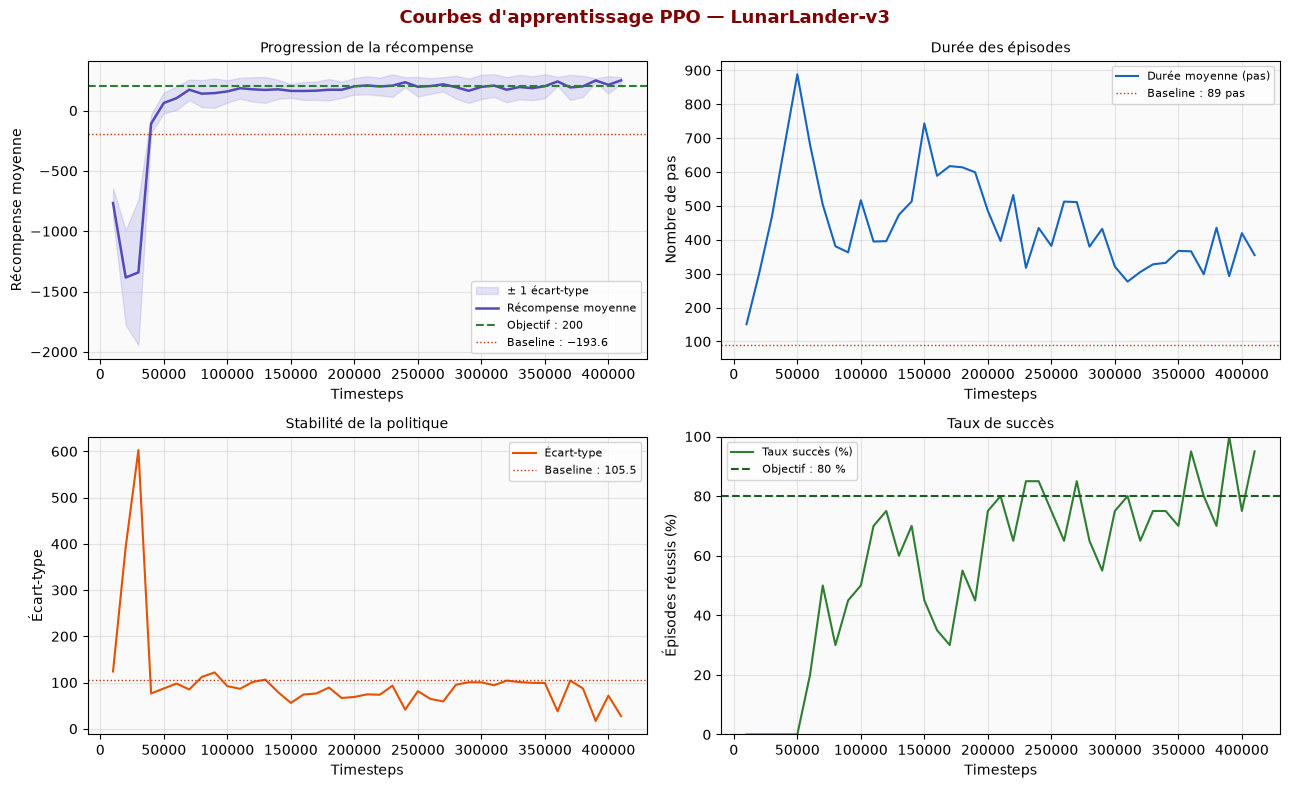


  Graphique sauvegardé....: courbes_apprentissage_ppo.png


In [8]:
# ============================================================
# CELLULE 5 — Courbes d'apprentissage depuis les logs eval
# ============================================================

import numpy             as np    # calcul vectoriel
import matplotlib.pyplot as plt   # tracé
from pathlib             import Path

# ----------------------------------------------------------
# Chargement des logs d'évaluation (EvalCallback)
# ----------------------------------------------------------
log_eval = np.load(
    str(LOGS_PPO_EVAL / 'evaluations.npz'),  # str(MODELS / 'eval_logs' / 'evaluations.npz'),
    allow_pickle=True
)

# Contenu du fichier evaluations.npz :
#   timesteps  : pas auquel l'évaluation a eu lieu
#   results    : tableau (n_eval, n_episodes) de récompenses
#   ep_lengths : longueurs des épisodes
timesteps   = log_eval['timesteps']           # axe X
resultats   = log_eval['results']             # shape (n_eval, n_ep)
moy_eval    = resultats.mean(axis=1)          # moyenne par évaluation
std_eval    = resultats.std(axis=1)           # écart-type par évaluation
longueurs_e = log_eval['ep_lengths'].mean(axis=1)  # durée moyenne

print("\n============================================================")
print("COURBES D'APPRENTISSAGE")
print("============================================================")
print(f"  Évaluations enregistrées: {len(timesteps)}")
print(f"  Première évaluation.....: {timesteps[0]:,} pas — {moy_eval[0]:+.1f} pts")
print(f"  Dernière évaluation.....: {timesteps[-1]:,} pas — {moy_eval[-1]:+.1f} pts")
print(f"  Meilleure évaluation....: {moy_eval.max():+.1f} pts")
print(f"  Objectif atteint........: {'✓ OUI' if moy_eval.max() >= 200 else '✗ NON'}")

# ----------------------------------------------------------
# Figure 4 panneaux
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(
    "Courbes d'apprentissage PPO — LunarLander-v3",
    fontsize=13, fontweight='bold', color='#800000'
)

# ── Panneau 1 : récompense moyenne avec bande d'incertitude
ax = axes[0, 0]
ax.fill_between(
    timesteps,
    moy_eval - std_eval,
    moy_eval + std_eval,
    alpha=0.2, color='#7F77DD', label='± 1 écart-type'
)
ax.plot(timesteps, moy_eval,
        color='#534AB7', linewidth=1.8, label='Récompense moyenne')
ax.axhline(200,  color='#2E7D32', linewidth=1.5,
           linestyle='--', label='Objectif : 200')
ax.axhline(-193.6, color='#BF360C', linewidth=1,
           linestyle=':', label='Baseline : −193.6')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Récompense moyenne')
ax.set_title('Progression de la récompense', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

# ── Panneau 2 : durée moyenne des épisodes
ax = axes[0, 1]
ax.plot(timesteps, longueurs_e,
        color='#1565C0', linewidth=1.5, label='Durée moyenne (pas)')
ax.axhline(89.3, color='#BF360C', linewidth=1,
           linestyle=':', label='Baseline : 89 pas')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Nombre de pas')
ax.set_title('Durée des épisodes', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

# ── Panneau 3 : écart-type (stabilité)
ax = axes[1, 0]
ax.plot(timesteps, std_eval,
        color='#E65100', linewidth=1.5, label='Écart-type')
ax.axhline(105.5, color='#BF360C', linewidth=1,
           linestyle=':', label='Baseline : 105.5')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Écart-type')
ax.set_title('Stabilité de la politique', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

# ── Panneau 4 : taux de succès (épisodes ≥ 200)
ax = axes[1, 1]
taux_succes_eval = (resultats >= 200).mean(axis=1) * 100
ax.plot(timesteps, taux_succes_eval,
        color='#2E7D32', linewidth=1.5, label='Taux succès (%)')
ax.axhline(80, color='#1B5E20', linewidth=1.5,
           linestyle='--', label='Objectif : 80 %')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Épisodes réussis (%)')
ax.set_title('Taux de succès', fontsize=10)
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt_path = MODELS / f"mission_{ts}_ppo_courbes_apprentissage.png"
plt.savefig(plt_path,
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('\n  Graphique sauvegardé....: courbes_apprentissage_ppo.png')


---
### [Cellule] 🔍 Evaluation PPO finale : 100 épisodes

L'évaluation finale utilise le **meilleur modèle sauvegardé** par
`EvalCallback`, pas nécessairement le dernier. Ce modèle est chargé
depuis `models/best_ppo/best_model.zip`.

**Critère officiel OpenClassrooms :** récompense moyenne ≥ 200
sur **100 épisodes** avec politique déterministe.

> Si la Cellule 4 a été interrompue, cette cellule peut être
> exécutée indépendamment en chargeant le modèle sauvegardé.



ÉVALUATION FINALE — MEILLEUR MODÈLE PPO
  Modèle chargé...........: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\best_ppo\best_model.zip

  Récompense moyenne......: +239.62
  Écart-type..............: 54.33
  Critère atteint (≥200)..: ✓ OUI

RAPPORT FINAL — 100 ÉPISODES
  Récompense moyenne......: +225.88
  Écart-type..............: 61.67
  Récompense minimale.....: -1.22
  Récompense maximale.....: +292.90
  Durée moyenne (pas).....: 387.6
  Épisodes réussis (≥200).: 85 / 100
  Taux de succès..........: 85.0 %
  ─────────────────────────────────────────────
  Amélioration / baseline.: +419.5 pts
  Critère officiel........: ✓ VALIDÉ
  Modèle sauvegardé......: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\mission_260623_101350_ppo_lunarlander_226_best.zip


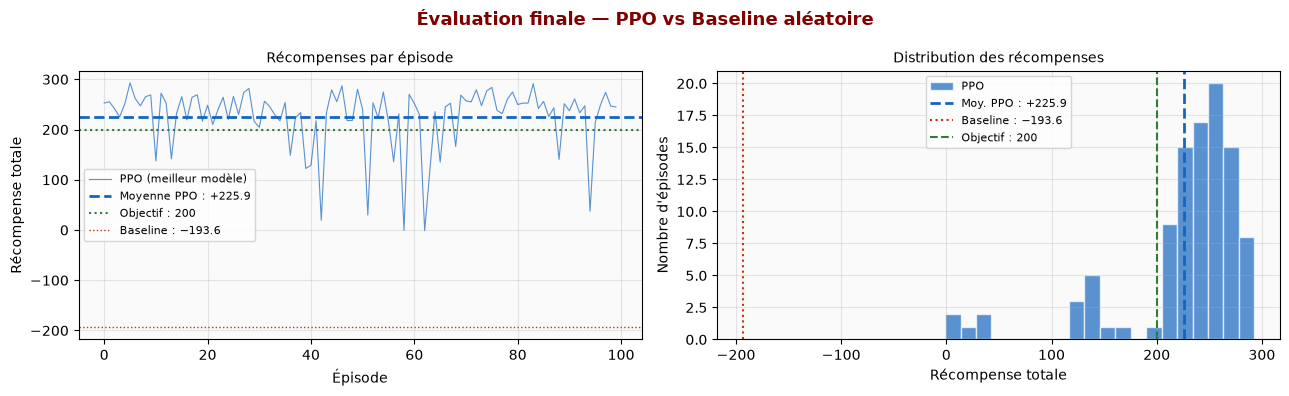


  Graphique sauvegardé....: evaluation_finale_ppo.png


In [9]:
# ============================================================
# CELLULE 6 — Évaluation finale du meilleur modèle PPO
# ============================================================

import numpy             as np
import matplotlib.pyplot as plt
from pathlib             import Path

from stable_baselines3                       import PPO
from stable_baselines3.common.evaluation     import evaluate_policy
from env_utils                               import make_env

from stable_baselines3.common.monitor import Monitor

# ----------------------------------------------------------
# Chargement du meilleur modèle
# ----------------------------------------------------------
chemin_best_ppo = MODELS / 'best_ppo' / 'best_model'
model_best_ppo  = PPO.load(str(chemin_best_ppo))    # chargement poids

print("\n============================================================")
print("ÉVALUATION FINALE — MEILLEUR MODÈLE PPO")
print("============================================================")
print(f"  Modèle chargé...........: {chemin_best_ppo}.zip")

# ----------------------------------------------------------
# Évaluation SB3 (evaluate_policy — 100 épisodes)
# ----------------------------------------------------------
# env_final = make_env(ENV_ID, render_mode=None, seed=SEED + 200)
env_final  = Monitor(make_env(ENV_ID, render_mode=None, seed=SEED + 200))

mean_reward, std_reward = evaluate_policy(
    model_best_ppo,
    env_final,
    n_eval_episodes = 100,   # 100 épisodes — critère officiel
    deterministic   = True,  # politique déterministe
    render          = False
)

print(f"\n  Récompense moyenne......: {mean_reward:+.2f}")
print(f"  Écart-type..............: {std_reward:.2f}")
print(f"  Critère atteint (≥200)..: {'✓ OUI' if mean_reward >= 200 else '✗ NON'}")

# ----------------------------------------------------------
# Boucle détaillée : métriques épisode par épisode
# ----------------------------------------------------------
env_detail   = make_env(ENV_ID, render_mode=None, seed=SEED + 300)
rewards_fin  = []
longueurs_f  = []
n_succes_f   = 0

for ep in range(100):
    obs, _       = env_detail.reset(seed=SEED + 300 + ep)
    total_r      = 0.0
    n_pas        = 0
    terminated   = False
    truncated    = False

    while not (terminated or truncated):
        # Politique déterministe — pas d'exploration
        action, _                = model_best_ppo.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env_detail.step(action)
        total_r += r
        n_pas   += 1

    rewards_fin.append(total_r)
    longueurs_f.append(n_pas)
    if total_r >= 200:
        n_succes_f += 1

env_detail.close()
env_final.close()

rewards_f = np.array(rewards_fin)

print("\n============================================================")
print("RAPPORT FINAL — 100 ÉPISODES")
print("============================================================")
print(f"  Récompense moyenne......: {rewards_f.mean():+.2f}")
print(f"  Écart-type..............: {rewards_f.std():.2f}")
print(f"  Récompense minimale.....: {rewards_f.min():+.2f}")
print(f"  Récompense maximale.....: {rewards_f.max():+.2f}")
print(f"  Durée moyenne (pas).....: {np.mean(longueurs_f):.1f}")
print(f"  Épisodes réussis (≥200).: {n_succes_f} / 100")
print(f"  Taux de succès..........: {n_succes_f:.1f} %")
print(f"  ─────────────────────────────────────────────")
print(f"  Amélioration / baseline.: {rewards_f.mean() - (-193.6):+.1f} pts")
print(f"  Critère officiel........: {'✓ VALIDÉ' if rewards_f.mean() >= 200 else '✗ NON ATTEINT'}")

# Sauvegarder les résultats pour les cellules suivantes
MEAN_REWARD_FINAL = rewards_f.mean()
STD_REWARD_FINAL  = rewards_f.std()

# ----------------------------------------------------------
# Sauvegarder avec le score du best model PPO
# ----------------------------------------------------------
nom_ppo      = f'mission_{ts}_ppo_lunarlander_{MEAN_REWARD_FINAL:.0f}_best'
chemin_ppo   = MODELS / f'{nom_ppo}.zip'
model_best_ppo.save(str(MODELS / nom_ppo))
print(f'  Modèle sauvegardé......: {chemin_ppo}')

# ----------------------------------------------------------
# Visualisation comparative baseline vs PPO
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    'Évaluation finale — PPO vs Baseline aléatoire',
    fontsize=13, fontweight='bold', color='#800000'
)

# Panneau gauche : récompenses par épisode
axes[0].plot(rewards_f, color='#1565C0',
             linewidth=0.8, alpha=0.7, label='PPO (meilleur modèle)')
axes[0].axhline(rewards_f.mean(), color='#1565C0',
                linewidth=2, linestyle='--',
                label=f'Moyenne PPO : {rewards_f.mean():+.1f}')
axes[0].axhline(200, color='#2E7D32',
                linewidth=1.5, linestyle=':',
                label='Objectif : 200')
axes[0].axhline(-193.6, color='#BF360C',
                linewidth=1, linestyle=':',
                label='Baseline : −193.6')
axes[0].set_xlabel('Épisode')
axes[0].set_ylabel('Récompense totale')
axes[0].set_title('Récompenses par épisode', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#FAFAFA')

# Panneau droit : comparaison histogrammes
axes[1].hist(rewards_f, bins=20, color='#1565C0',
             alpha=0.7, label='PPO', edgecolor='white')
axes[1].axvline(rewards_f.mean(), color='#1565C0',
                linewidth=2, linestyle='--',
                label=f'Moy. PPO : {rewards_f.mean():+.1f}')
axes[1].axvline(-193.6, color='#BF360C',
                linewidth=1.5, linestyle=':',
                label='Baseline : −193.6')
axes[1].axvline(200, color='#2E7D32',
                linewidth=1.5, linestyle='--',
                label='Objectif : 200')
axes[1].set_xlabel('Récompense totale')
axes[1].set_ylabel("Nombre d'épisodes")
axes[1].set_title('Distribution des récompenses', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#FAFAFA')

plt.tight_layout()

plt_path = MODELS / f"mission_{ts}_ppo_evaluation_finale.png"
plt.savefig(plt_path,
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('\n  Graphique sauvegardé....: evaluation_finale_ppo.png')


---
### [Cellule] 🎥 Animation PPO de l'atterrissage + sauvegarde MP4

Cette cellule produit le **livrable vidéo** exigé par OpenClassrooms :
un clip de 20 à 30 secondes montrant un atterrissage réussi.

L'agent joue un épisode complet en mode `rgb_array`. Chaque frame
est capturée et assemblée en animation matplotlib, puis sauvegardée
en MP4 (ou GIF si FFmpeg n'est pas disponible).


In [10]:
# ============================================================
# CELLULE 7 — Animation atterrissage + sauvegarde MP4/GIF
# ============================================================

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib.animation   import FFMpegWriter, PillowWriter
from IPython.display         import HTML, display
from env_utils               import make_env
from stable_baselines3       import PPO
from pathlib                 import Path

# ----------------------------------------------------------
# Charger le meilleur modèle (si pas déjà en mémoire)
# ----------------------------------------------------------
chemin_best_ppo = MODELS / 'best_ppo' / 'best_model'
model_anim  = PPO.load(str(chemin_best_ppo))

# ----------------------------------------------------------
# Jouer un épisode et capturer les frames
# ----------------------------------------------------------
env_anim = make_env(ENV_ID, render_mode='rgb_array', seed=SEED + 999)
obs, _   = env_anim.reset(seed=SEED + 999)

frames       = []     # frames RGB pour l'animation
rewards_anim = []     # récompenses par pas
total_r      = 0.0
terminated   = False
truncated    = False

while not (terminated or truncated):
    frame                       = env_anim.render()  # frame RGB (H, W, 3)
    frames.append(frame)
    action, _                   = model_anim.predict(obs, deterministic=True)
    obs, r, terminated, truncated, _ = env_anim.step(action)
    total_r += r
    rewards_anim.append(total_r)

env_anim.close()

print("\n============================================================")
print("ANIMATION ATTERRISSAGE")
print("============================================================")
print(f"  Frames capturées........: {len(frames)}")
print(f"  Récompense épisode......: {total_r:+.2f}")
print(f"  Atterrissage réussi.....: {'✓ OUI' if total_r >= 200 else '✗ NON (rejouer)'}")

# ----------------------------------------------------------
# Construction de l'animation matplotlib
# ----------------------------------------------------------
fig_anim, ax_anim = plt.subplots(figsize=(7, 5))
fig_anim.patch.set_facecolor('black')
ax_anim.axis('off')

im        = ax_anim.imshow(frames[0])
titre_ax  = ax_anim.set_title(
    f'Eagle-1 — Atterrissage  |  Récompense : 0.00',
    color='white', fontsize=10
)

def update_frame(i):
    """Met à jour la frame et le titre à chaque pas."""
    im.set_data(frames[i])
    titre_ax.set_text(
        f'Eagle-1 — Atterrissage  |  '
        f'Récompense cumulée : {rewards_anim[i]:+.1f}'
    )
    return [im, titre_ax]

anim = animation.FuncAnimation(
    fig_anim,
    update_frame,
    frames     = len(frames),
    interval   = 33,          # ~30 fps
    blit       = True
)


# ----------------------------------------------------------
# Affichage inline JupyterLab
# ----------------------------------------------------------
plt.close(fig_anim)
display(HTML(anim.to_html5_video()))



ANIMATION ATTERRISSAGE
  Frames capturées........: 333
  Récompense épisode......: +270.09
  Atterrissage réussi.....: ✓ OUI


### [Cellule] 💾 Animation PPO. Sauvegarder 

In [11]:
# ----------------------------------------------------------
# Sauvegarde MP4 (FFmpeg) ou GIF (Pillow) selon disponibilité
# ----------------------------------------------------------
nom_video = MODELS / f'mission_{ts}_ppo_atterrissage_{total_r:.0f}pts'

try:
    writer_mp4 = FFMpegWriter(fps=30, metadata={'title': 'Eagle-1 Landing'})
    anim.save(f'{nom_video}.mp4', writer=writer_mp4)
    print(f'  Vidéo MP4 sauvegardée...: {nom_video}.mp4')
except Exception:
    # Fallback GIF si FFmpeg absent
    writer_gif = PillowWriter(fps=25)
    anim.save(f'{nom_video}.gif', writer=writer_gif)
    print(f'  GIF sauvegardé..........: {nom_video}.gif')
    print('  (FFmpeg absent — installer avec : conda install ffmpeg)')


  Vidéo MP4 sauvegardée...: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\mission_260623_101350_ppo_atterrissage_270pts.mp4


# Étape 2 - Optimisez les hyperparamètres de votre agent

---
## Point 1. Optimisation des hyperparamètres (3 configurations)

Pour explorer l'effet des hyperparamètres, on compare **3 configurations**
en ne modifiant **qu'un seul paramètre à la fois** — principe fondamental
de l'expérimentation contrôlée.

| Config | Modification | Hypothèse |
|--------|-------------|----------|
| **V1** (référence) | Hyperparamètres de la Cellule 3 | Baseline PPO |
| **V2** | `learning_rate = 1e-3` | LR plus élevé → convergence plus rapide ? |
| **V3** | `ent_coef = 0.05` | Plus d'exploration → meilleur score final ? |

Chaque config est entraînée sur **200 000 pas** (au lieu de 500k)
pour comparer rapidement sans attendre la convergence complète.


### [Cellule] 🛠️ Hyperparamètres PPO pour 3 configurations 

In [12]:
# ============================================================
# CELLULE 8 — Comparaison de 3 configurations PPO
# ⚠ Durée estimée : 3 × 10 min ≈ 30 min sur CPU
# ============================================================

import numpy             as np
import matplotlib.pyplot as plt
import time

from stable_baselines3                       import PPO
from stable_baselines3.common.evaluation     import evaluate_policy
from stable_baselines3.common.env_util       import make_vec_env
from env_utils                               import make_env

# ----------------------------------------------------------
# Définition des 3 configurations
# Règle : un seul paramètre change par rapport à V1
# ----------------------------------------------------------
CONFIGS = [
    {
        'nom'          : 'V1 — Référence',
        'learning_rate': 3e-4,    # valeur de référence (Cellule 3)
        'ent_coef'     : 0.01,    # valeur de référence
        'couleur'      : '#534AB7',
    },
    {
        'nom'          : 'V2 — LR élevé',
        'learning_rate': 1e-3,    # ← seul paramètre modifié
        'ent_coef'     : 0.01,
        'couleur'      : '#E65100',
    },
    {
        'nom'          : 'V3 — Plus exploration',
        'learning_rate': 3e-4,
        'ent_coef'     : 0.05,    # ← seul paramètre modifié
        'couleur'      : '#1565C0',
    },
]

TIMESTEPS_COMPARAISON = 200_000   # réduit pour comparaison rapide
resultats_configs     = {}         # stockage des résultats

print("\n============================================================")
print("COMPARAISON DE CONFIGURATIONS PPO")
print("============================================================")



COMPARAISON DE CONFIGURATIONS PPO


### [Cellule] 🏋️‍♀️ Entraînement PPO pour 3 configurations

In [13]:
from stable_baselines3.common.monitor import Monitor


# ----------------------------------------------------------
# Entraînement de chaque configuration
# ----------------------------------------------------------
for cfg in CONFIGS:
    print("\n============================================================")
    print(f"\n  Configuration : {cfg['nom']}")
    print(f"  learning_rate : {cfg['learning_rate']}  |  "
          f"ent_coef : {cfg['ent_coef']}")

    env_cfg  = make_vec_env(ENV_ID, n_envs=1, seed=SEED)
    
    # env_eval_cfg = make_env(ENV_ID, render_mode=None, seed=SEED + 50)

    env_eval_cfg = Monitor(make_env(ENV_ID, render_mode=None, seed=SEED + 50))

    model_cfg = PPO(
        policy         = POLICY,
        env            = env_cfg,
        learning_rate  = cfg['learning_rate'],
        n_steps        = N_STEPS,
        batch_size     = BATCH_SIZE,
        n_epochs       = N_EPOCHS,
        gamma          = GAMMA,
        gae_lambda     = GAE_LAMBDA,
        clip_range     = CLIP_RANGE,
        ent_coef       = cfg['ent_coef'],
        seed           = SEED,
        verbose        = 0          # silencieux pour lisibilité
    )

    debut_cfg = time.time()
    model_cfg.learn(
            total_timesteps=TIMESTEPS_COMPARAISON,
        progress_bar      = True)
    duree_cfg = time.time() - debut_cfg

    # Évaluation sur 50 épisodes
    mean_r, std_r = evaluate_policy(
        model_cfg, env_eval_cfg,
        n_eval_episodes=50,
        deterministic=True
    )

    resultats_configs[cfg['nom']] = {
        'mean': mean_r,
        'std' : std_r,
        'duree': duree_cfg,
    }

    print(f"  Récompense moyenne : {mean_r:+.2f} ± {std_r:.2f}")
    print(f"  Durée             : {duree_cfg/60:.1f} min")

    # Sauvegarde du modèle avec son score
    nom_cfg = cfg['nom'].split('—')[0].strip().lower().replace(' ', '_')
    model_cfg.save(str(MODELS / f'mission_{ts}_ppo_compare_{nom_cfg}_{mean_r:.0f}'))

    env_cfg.close()
    env_eval_cfg.close()



Output()



  Configuration : V1 — Référence
  learning_rate : 0.0003  |  ent_coef : 0.01


Output()

  Récompense moyenne : +188.80 ± 80.52
  Durée             : 14.7 min


  Configuration : V2 — LR élevé
  learning_rate : 0.001  |  ent_coef : 0.01


Output()

  Récompense moyenne : +206.08 ± 104.63
  Durée             : 15.4 min


  Configuration : V3 — Plus exploration
  learning_rate : 0.0003  |  ent_coef : 0.05


  Récompense moyenne : +63.59 ± 139.84
  Durée             : 14.5 min


### [Cellule] 📈 Visualisation PPO pour 3 configurations

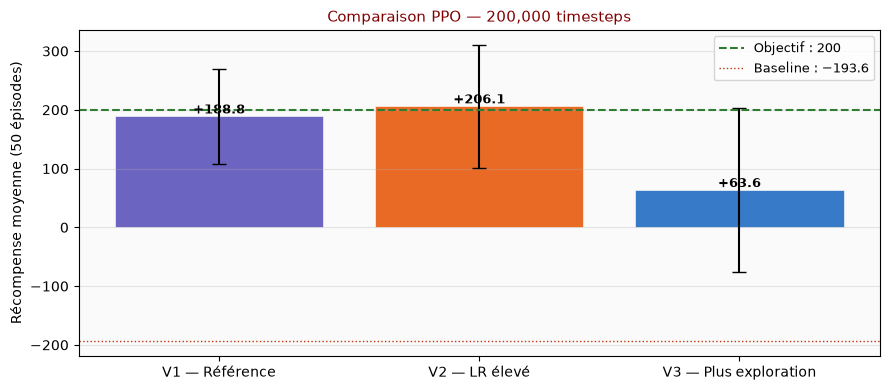


  Graphique sauvegardé....: comparaison_configs_ppo.png


In [14]:
# ----------------------------------------------------------
# Graphique de comparaison
# ----------------------------------------------------------
noms   = list(resultats_configs.keys())
moyens = [resultats_configs[n]['mean'] for n in noms]
stds   = [resultats_configs[n]['std']  for n in noms]
couleurs = [cfg['couleur'] for cfg in CONFIGS]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(noms, moyens, yerr=stds,
              color=couleurs, alpha=0.85,
              capsize=5, edgecolor='white', linewidth=0.5)
ax.axhline(200, color='#2E7D32', linewidth=1.5,
           linestyle='--', label='Objectif : 200')
ax.axhline(-193.6, color='#BF360C', linewidth=1,
           linestyle=':', label='Baseline : −193.6')
ax.set_ylabel('Récompense moyenne (50 épisodes)')
ax.set_title(
    f'Comparaison PPO — {TIMESTEPS_COMPARAISON:,} timesteps',
    fontsize=11, color='#800000'
)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.set_facecolor('#FAFAFA')

# Valeurs sur les barres
for bar, m in zip(bars, moyens):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{m:+.1f}',
        ha='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()

plt_path = MODELS / f"mission_{ts}_ppo_comparaison_3_configs.png"
plt.savefig(plt_path,
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('\n  Graphique sauvegardé....: comparaison_configs_ppo.png')

### Tableau de synthèse

In [15]:
# ----------------------------------------------------------
# Tableau de synthèse
# ----------------------------------------------------------
print("\n============================================================")
print("SYNTHÈSE COMPARAISON")
print("============================================================")
print(f"  {'Configuration':<28} {'Moy':>8} {'Std':>8} {'Durée':>8}")
print(f"  {'─'*28} {'─'*8} {'─'*8} {'─'*8}")
for nom, res in resultats_configs.items():
    print(f"  {nom:<28} {res['mean']:>+8.1f} "
          f"{res['std']:>8.1f} {res['duree']/60:>7.1f}m")

# Identifier le meilleur
meilleur = max(resultats_configs, key=lambda k: resultats_configs[k]['mean'])
print(f"\n  Meilleure configuration.: {meilleur}")



SYNTHÈSE COMPARAISON
  Configuration                     Moy      Std    Durée
  ──────────────────────────── ──────── ──────── ────────
  V1 — Référence                 +188.8     80.5    14.7m
  V2 — LR élevé                  +206.1    104.6    15.4m
  V3 — Plus exploration           +63.6    139.8    14.5m

  Meilleure configuration.: V2 — LR élevé


---
## Point 2 Comparaison PPO avec DQN

DQN a été étudié en détail dans l'**Exercice 3** (CartPole-v1).
Ici, on l'applique directement à LunarLander-v3 via SB3 pour
mesurer son comportement face à PPO.

**Différence clé PPO vs DQN sur LunarLander :**

| Aspect | PPO | DQN |
|--------|-----|-----|
| Type | On-policy | Off-policy |
| Mémoire | Pas de replay buffer | Replay buffer (Ex.3) |
| Stabilité | Clipping PPO | Target network |
| Efficacité données | Faible (jette après update) | Haute (rejoue transitions) |
| Typiquement plus rapide sur LunarLander | ✓ | ✗ |


### [Cellule] 🛠️ Hyperparamètres DQN 

In [16]:
# ----------------------------------------------------------
# Hyperparamètres DQN pour LunarLander
# ----------------------------------------------------------
DQN_LEARNING_RATE      = 1e-3          # plus élevé que PPO — DQN tolère
DQN_BUFFER_SIZE        = 50_000        # taille du replay buffer
DQN_LEARNING_STARTS    = 1_000         # pas avant la première mise à jour
DQN_BATCH_SIZE         = 64            # taille des mini-batchs
DQN_GAMMA              = 0.99          # facteur d'actualisation
DQN_TARGET_UPDATE_INT  = 1_000         # fréquence mise à jour target network
DQN_EXPLORATION_FRAC   = 0.12          # fraction timesteps pour epsilon
DQN_EXPLORATION_FINAL  = 0.05          # epsilon final
DQN_TOTAL_TIMESTEPS    = 500_000       # même budget que PPO

# ----------------------------------------------------------

DQN_EXPLORATION_FRAC  = 0.25   # ✅ exploración hasta 125k → política más robusta
DQN_TARGET_UPDATE_INT = 5_000    # ✅ target más estable → Q-values más consistentes
DQN_BUFFER_SIZE       = 100_000   # ✅ más diversidad de experiencias en el replay



### [Cellule] 🏋️‍♀️ Entraînement DQN 

In [17]:
# ============================================================
# CELLULE 9 — DQN SB3 sur LunarLander-v3
# ⚠ Durée estimée : 20-30 min sur CPU
# ============================================================

import numpy             as np
import matplotlib.pyplot as plt
import time

from stable_baselines3                   import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from env_utils                           import make_env


print("\n============================================================")
print("ENTRAÎNEMENT DQN — LUNARLANDER-V3")
print("============================================================")
print(f"  buffer_size.............: {DQN_BUFFER_SIZE:,}")
print(f"  learning_rate...........: {DQN_LEARNING_RATE}")
print(f"  target_update_interval..: {DQN_TARGET_UPDATE_INT:,}")
print(f"  exploration_fraction....: {DQN_EXPLORATION_FRAC}")
print(f"  total_timesteps.........: {DQN_TOTAL_TIMESTEPS:,}")

# ----------------------------------------------------------
# Environnements
# ----------------------------------------------------------
env_dqn      = make_env(ENV_ID, render_mode=None, seed=SEED)
env_eval_dqn = make_env(ENV_ID, render_mode=None, seed=SEED + 400)

# ----------------------------------------------------------
# Callbacks DQN — identiques à PPO
# ----------------------------------------------------------
stop_callback_dqn = StopTrainingOnRewardThreshold(
    reward_threshold = REWARD_THRESHOLD,  # même seuil que PPO : 250
    verbose          = 1
)

eval_callback_dqn = EvalCallback(
    env_eval_dqn,
    best_model_save_path = str(MODELS / 'best_dqn'),  # dossier séparé de PPO
    log_path             = str(LOGS_DQN_EVAL),         # logs évaluation DQN
    eval_freq            = EVAL_FREQ,                  # tous les 10 000 pas
    n_eval_episodes      = N_EVAL_EPISODES,            # 20 épisodes par éval
    deterministic        = True,
    render               = False,
    callback_on_new_best = stop_callback_dqn,          # early stopping
    verbose              = 1
)

# ----------------------------------------------------------
# Modèle DQN
# ----------------------------------------------------------
model_dqn = DQN(
    policy                  = 'MlpPolicy',
    env                     = env_dqn,
    learning_rate           = DQN_LEARNING_RATE,
    buffer_size             = DQN_BUFFER_SIZE,
    learning_starts         = DQN_LEARNING_STARTS,
    batch_size              = DQN_BATCH_SIZE,
    gamma                   = DQN_GAMMA,
    target_update_interval  = DQN_TARGET_UPDATE_INT,
    exploration_fraction    = DQN_EXPLORATION_FRAC,
    exploration_final_eps   = DQN_EXPLORATION_FINAL,
    tensorboard_log         = str(LOGS_DQN_TRAIN),
    seed                    = SEED,
    verbose                 = 0
)

debut_dqn = time.time()
model_dqn.learn(
    total_timesteps   = DQN_TOTAL_TIMESTEPS,
    tb_log_name       = 'dqn_eagle1_v1',
    callback          = eval_callback_dqn,
    progress_bar      = True
)
duree_dqn = time.time() - debut_dqn

Output()


ENTRAÎNEMENT DQN — LUNARLANDER-V3
  buffer_size.............: 100,000
  learning_rate...........: 0.001
  target_update_interval..: 5,000
  exploration_fraction....: 0.25
  total_timesteps.........: 500,000


C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\.venv\Lib\site-packages\stable_baselines3\common\evaluation.py:71: 
UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=10000, episode_reward=-179.04 +/- 27.28

Episode length: 1000.00 +/- 0.00

...

Eval num_timesteps=490000, episode_reward=229.87 +/- 19.97

Episode length: 463.05 +/- 148.93

New best mean reward!

Eval num_timesteps=500000, episode_reward=213.15 +/- 30.03

Episode length: 557.85 +/- 150.43

### [Cellule] 🔍 Evaluation DQN 

In [18]:

# ----------------------------------------------------------
# Évaluation DQN
# ----------------------------------------------------------
mean_dqn, std_dqn = evaluate_policy(
    model_dqn, 
    env_eval_dqn,
    n_eval_episodes=100,
    deterministic=True
)

env_dqn.close()
env_eval_dqn.close()

# Sauvegarde avec le score
nom_dqn = f'mission_{ts}_dqn_lunarlander_{mean_dqn:.0f}'
model_dqn.save(str(MODELS / nom_dqn))

print("\n============================================================")
print("RÉSULTATS DQN")
print("============================================================")
print(f"  Récompense moyenne DQN..: {mean_dqn:+.2f} ± {std_dqn:.2f}")
print(f"  Durée entraînement......: {duree_dqn/60:.1f} min")
print(f"  Modèle sauvegardé.......: {nom_dqn}.zip")



RÉSULTATS DQN
  Récompense moyenne DQN..: +222.04 ± 30.89
  Durée entraînement......: 35.5 min
  Modèle sauvegardé.......: mission_260623_101350_dqn_lunarlander_222.zip


### [Cellule] 🔍 Evaluation DQN Meilleur Modele

In [19]:
# ----------------------------------------------------------
# Évaluation finale depuis le meilleur modèle sauvegardé
# ----------------------------------------------------------
from stable_baselines3 import DQN as DQN_load


chemin_dqn_best = MODELS / 'best_dqn' / 'best_model'
model_dqn_best = DQN.load(str(chemin_dqn_best))

mean_dqn, std_dqn = evaluate_policy(
    model_dqn_best, 
    env_eval_dqn,
    n_eval_episodes = 100,
    deterministic   = True
)

print(f'  Récompense best DQN....: {mean_dqn:+.2f} ± {std_dqn:.2f}')

env_dqn.close()
env_eval_dqn.close()

# ----------------------------------------------------------
# Sauvegarder avec le score du best model
# ----------------------------------------------------------
nom_dqn    = f'mission_{ts}_dqn_lunarlander_{mean_dqn:.0f}_best'
chemin_dqn = MODELS / 'best_dqn' / f'{nom_dqn}.zip'
model_dqn_best.save(str(MODELS / nom_dqn))
print(f'  Modèle sauvegardé......: {chemin_dqn}')

  Récompense best DQN....: +225.67 ± 33.38
  Modèle sauvegardé......: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\best_dqn\mission_260623_101350_dqn_lunarlander_226_best.zip


### [Cellule] 🎥 Animation DQN de l'atterrissage + sauvegarde MP4

In [20]:
# ============================================================
# CELLULE — Animation atterrissage DQN + sauvegarde MP4/GIF
# ============================================================

# — Calcul et visualisation
import numpy                    as np    # tableaux numériques
import matplotlib.pyplot        as plt   # création de la figure
import matplotlib.animation     as animation  # animation frame par frame

# — Encodage et affichage
from matplotlib.animation import FFMpegWriter  # sauvegarde MP4
from matplotlib.animation import PillowWriter  # sauvegarde GIF (fallback)
from IPython.display      import HTML, display # affichage inline Jupyter

# — Environnement et modèle
from stable_baselines3    import DQN         # algorithme DQN SB3
from env_utils            import make_env    # création environnement

# ----------------------------------------------------------
# Charger le meilleur modèle DQN
# ----------------------------------------------------------
chemin_dqn_best = MODELS / 'best_dqn' / 'best_model'
model_dqn_anim  = DQN.load(str(chemin_dqn_best))

# ----------------------------------------------------------
# Jouer un épisode et capturer les frames RGB
# ----------------------------------------------------------
env_anim_dqn = make_env(ENV_ID, render_mode='rgb_array',
                         seed=SEED + 998)
obs, _       = env_anim_dqn.reset(seed=SEED + 998)

frames_dqn   = []    # frames RGB (H, W, 3) — une par pas
rewards_dqn  = []    # récompense cumulée à chaque pas
total_r_dqn  = 0.0   # accumulateur de récompense
terminated   = False
truncated    = False

while not (terminated or truncated):
    frame = env_anim_dqn.render()           # capturer AVANT l'action
    frames_dqn.append(frame)

    # Politique déterministe — epsilon = 0
    action, _                             = model_dqn_anim.predict(
                                              obs, deterministic=True)
    obs, r, terminated, truncated, _     = env_anim_dqn.step(action)
    total_r_dqn += float(r)
    rewards_dqn.append(total_r_dqn)

env_anim_dqn.close()

print("\n============================================================")
print("ANIMATION ATTERRISSAGE — DQN")
print("============================================================")
print(f"  Frames capturées........: {len(frames_dqn)}")
print(f"  Récompense épisode......: {total_r_dqn:+.2f}")
print(f"  Atterrissage réussi.....: "
      f"{'✓ OUI' if total_r_dqn >= 200 else '✗ NON (rejouer)'}")

# ----------------------------------------------------------
# Construction de l'animation matplotlib
# ----------------------------------------------------------
fig_dqn, ax_dqn = plt.subplots(figsize=(7, 5))
fig_dqn.patch.set_facecolor('black')
ax_dqn.axis('off')

im_dqn    = ax_dqn.imshow(frames_dqn[0])
titre_dqn = ax_dqn.set_title(
    'Eagle-1 — Atterrissage DQN  |  Récompense : 0.00',
    color='white', fontsize=10
)

def update_frame_dqn(i):
    """Met à jour la frame et le titre à chaque pas."""
    im_dqn.set_data(frames_dqn[i])
    titre_dqn.set_text(
        f'Eagle-1 — Atterrissage DQN  |  '
        f'Récompense cumulée : {rewards_dqn[i]:+.1f}'
    )
    return [im_dqn, titre_dqn]

anim_dqn = animation.FuncAnimation(
    fig_dqn,
    update_frame_dqn,
    frames   = len(frames_dqn),
    interval = 33,                           # ~30 fps
    blit     = True
)

# ----------------------------------------------------------
# Affichage inline JupyterLab — AVANT sauvegarde
# ----------------------------------------------------------
plt.close(fig_dqn)
display(HTML(anim_dqn.to_html5_video()))




ANIMATION ATTERRISSAGE — DQN
  Frames capturées........: 496
  Récompense épisode......: +234.34
  Atterrissage réussi.....: ✓ OUI


### [Cellule] 💾 Animation DQN. Sauvegarder 

In [21]:
# ----------------------------------------------------------
# Sauvegarde MP4 (FFmpeg) ou GIF (Pillow) selon disponibilité
# ----------------------------------------------------------
nom_video_dqn = MODELS / f'mission_{ts}_dqn_atterrissage_{total_r_dqn:.0f}pts'

try:
    writer_mp4 = FFMpegWriter(
        fps      = 30,
        metadata = {'title': 'Eagle-1 DQN Landing'}
    )
    anim_dqn.save(f'{nom_video_dqn}.mp4', writer=writer_mp4)
    print(f'\n  Vidéo MP4 sauvegardée...: {nom_video_dqn}.mp4')

except Exception:
    writer_gif = PillowWriter(fps=25)
    anim_dqn.save(f'{nom_video_dqn}.gif', writer=writer_gif)
    print(f'\n  GIF sauvegardé..........: {nom_video_dqn}.gif')
    print('  (FFmpeg absent — installer: conda install ffmpeg)')


  Vidéo MP4 sauvegardée...: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\mission_260623_101350_dqn_atterrissage_234pts.mp4


### [Cellule] ⚖️ Tableau comparatif PPO vs DQN

In [22]:
# ----------------------------------------------------------
# Tableau comparatif PPO vs DQN
# ----------------------------------------------------------
print("\n============================================================")
print("COMPARAISON PPO vs DQN")
print("============================================================")
print(f"  {'Métrique':<28} {'PPO':>12} {'DQN':>12}")
print(f"  {'─'*28} {'─'*12} {'─'*12}")
print(f"  {'Récompense moyenne':<28} "
      f"{MEAN_REWARD_FINAL:>+12.2f} {mean_dqn:>+12.2f}")
print(f"  {'Écart-type':<28} "
      f"{STD_REWARD_FINAL:>12.2f} {std_dqn:>12.2f}")
print(f"  {'Critère ≥200 atteint':<28} "
      f"{'✓ OUI' if MEAN_REWARD_FINAL >= 200 else '✗ NON':>12} "
      f"{'✓ OUI' if mean_dqn >= 200 else '✗ NON':>12}")
print(f"  {'Baseline aléatoire':<28} {'−193.6':>12} {'−193.6':>12}")


COMPARAISON PPO vs DQN
  Métrique                              PPO          DQN
  ──────────────────────────── ──────────── ────────────
  Récompense moyenne                +225.88      +225.67
  Écart-type                          61.67        33.38
  Critère ≥200 atteint                ✓ OUI        ✓ OUI
  Baseline aléatoire                 −193.6       −193.6


---
### Cellule 10. Sauvegarde finale et métadonnées JSON

Cette cellule finalise le livrable en sauvegardant :

1. Le **modèle SB3** renommé avec son score final (`ppo_lunarlander_XXX.zip`)
2. Un fichier **JSON de métadonnées** contenant tous les hyperparamètres,
   les résultats, et la date — traçabilité complète du run.

Ces deux fichiers constituent le cœur du livrable notebook.


In [23]:
# ============================================================
# CELLULE 10 — Sauvegarde finale + métadonnées JSON
# ============================================================

import json
import datetime
import shutil
import numpy as np

from pathlib import Path
from stable_baselines3 import PPO

# ----------------------------------------------------------
# Fonction de sérialisation numpy → Python natif
# ----------------------------------------------------------
def to_serializable(obj):
    """Convertit les types numpy en types Python pour JSON."""
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray):  return obj.tolist()
    return obj

# ----------------------------------------------------------
# Fonction utilitaire — écrire un JSON de métadonnées
# ----------------------------------------------------------
def sauvegarder_json(chemin_zip, algorithme, mean_r, std_r,
                     hyperparametres, critere_valide):
    """
    Sauvegarde un JSON de métadonnées à côté du .zip correspondant.
    Fonctionne pour best_ppo/best_model.zip et mission_*.zip.
    """
    chemin_json = chemin_zip.with_suffix('.json')

    metadata = {
        # Identification
        'projet'           : 'Eagle-1 — AstroDynamics',
        'auteur'           : 'Cerezo_Rafael',
        'date'             : ts,
        'fichier_modele'   : chemin_zip.name,

        # Environnement
        'environnement'    : ENV_ID,
        'observation_space': 'Box(8,) float32',
        'action_space'     : 'Discrete(4)',

        # Algorithme
        'algorithme'       : algorithme,
        'policy'           : POLICY,
        'total_timesteps'  : TOTAL_TIMESTEPS if algorithme == 'PPO'
                             else DQN_TOTAL_TIMESTEPS,

        # Hyperparamètres
        'hyperparametres'  : hyperparametres,

        # Résultats évaluation finale
        'resultats'        : {
            'mean_reward'    : to_serializable(mean_r),
            'std_reward'     : to_serializable(std_r),
            'critere_valide' : bool(critere_valide),
            'n_eval_episodes': 100,
        },

        # Référence baseline
        'baseline_aleatoire': {
            'mean_reward' : -193.6,
            'std_reward'  : 105.5,
            'taux_succes' : 0.0,
        },
        # Comparaison DQN
        'comparaison_dqn'  : {
            'mean_reward'   : to_serializable(mean_dqn),
            'std_reward'    : to_serializable(std_dqn),
        },
    }

    with open(chemin_json, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    return chemin_json

# ----------------------------------------------------------
# Hyperparamètres PPO et DQN (pour les JSON)
# ----------------------------------------------------------
HP_PPO = {
    'learning_rate' : LEARNING_RATE,
    'n_steps'       : N_STEPS,
    'batch_size'    : BATCH_SIZE,
    'n_epochs'      : N_EPOCHS,
    'gamma'         : GAMMA,
    'gae_lambda'    : GAE_LAMBDA,
    'clip_range'    : CLIP_RANGE,
    'ent_coef'      : ENT_COEF,
    'vf_coef'       : VF_COEF,
    'max_grad_norm' : MAX_GRAD_NORM,
}
HP_DQN = {
    'learning_rate'      : DQN_LEARNING_RATE,
    'buffer_size'        : DQN_BUFFER_SIZE,
    'batch_size'         : DQN_BATCH_SIZE,
    'gamma'              : DQN_GAMMA,
    'target_update_int'  : DQN_TARGET_UPDATE_INT,
    'exploration_frac'   : DQN_EXPLORATION_FRAC,
    'exploration_final'  : DQN_EXPLORATION_FINAL,
}

print("\n============================================================")
print("SAUVEGARDE FINALE — MODÈLES + MÉTADONNÉES JSON")
print("============================================================")

# ----------------------------------------------------------
# 1. PPO — modèle final avec score dans le nom
# ----------------------------------------------------------
nom_final   = f'mission_{ts}_ppo_lunarlander_{MEAN_REWARD_FINAL:.0f}'
src_ppo     = MODELS / 'best_ppo' / 'best_model.zip'
dst_ppo     = MODELS / f'{nom_final}.zip'
shutil.copy2(str(src_ppo), str(dst_ppo))

json_ppo = sauvegarder_json(
    dst_ppo, 'PPO',
    MEAN_REWARD_FINAL, STD_REWARD_FINAL,
    HP_PPO, MEAN_REWARD_FINAL >= 200
)
print(f"  PPO modèle final........: {dst_ppo.name}")
print(f"  PPO JSON................: {json_ppo.name}")

# ----------------------------------------------------------
# 2. PPO — best_model.zip (JSON à côté dans best_ppo/)
# ----------------------------------------------------------
json_best_ppo = sauvegarder_json(
    src_ppo, 'PPO',
    MEAN_REWARD_FINAL, STD_REWARD_FINAL,
    HP_PPO, MEAN_REWARD_FINAL >= 200
)
print(f"  best_ppo JSON...........: {json_best_ppo.name}")

# ----------------------------------------------------------
# 3. DQN — best_model.zip (JSON à côté dans best_dqn/)
# ----------------------------------------------------------
chemin_best_dqn = MODELS / 'best_dqn' / 'best_model.zip'
if chemin_best_dqn.exists():
    json_best_dqn = sauvegarder_json(
        chemin_best_dqn, 'DQN',
        mean_dqn, std_dqn,
        HP_DQN, mean_dqn >= 200
    )
    print(f"  best_dqn JSON...........: {json_best_dqn.name}")
else:
    print(f"  best_dqn................: non disponible")

# ----------------------------------------------------------
# 4. DQN — modèle final avec score dans le nom
# ----------------------------------------------------------
nom_dqn  = f'mission_{ts}_dqn_lunarlander_{mean_dqn:.0f}'
dst_dqn  = MODELS / f'{nom_dqn}.zip'
if chemin_best_dqn.exists():
    shutil.copy2(str(chemin_best_dqn), str(dst_dqn))
    json_dqn = sauvegarder_json(
        dst_dqn, 'DQN',
        mean_dqn, std_dqn,
        HP_DQN, mean_dqn >= 200
    )
    print(f"  DQN modèle final........: {dst_dqn.name}")
    print(f"  DQN JSON................: {json_dqn.name}")

# ----------------------------------------------------------
# Récapitulatif final
# ----------------------------------------------------------
print("\n============================================================")
print("RÉCAPITULATIF MISSION EAGLE-1")
print("============================================================")
print(f"  Baseline aléatoire......: −193.6 pts  (0 % succès)")
print(f"  PPO — résultat final....: {MEAN_REWARD_FINAL:+.1f} pts "
      f"({'✓' if MEAN_REWARD_FINAL >= 200 else '✗'})")
print(f"  DQN — résultat final....: {mean_dqn:+.1f} pts "
      f"({'✓' if mean_dqn >= 200 else '✗'})")
print(f"  Amélioration totale.....: "
      f"{MEAN_REWARD_FINAL - (-193.6):+.1f} pts")
print()

print("\n============================================================")
print("\n  Fichiers sauvegardés pour PPO :")
print(f"    ✓  {dst_ppo.name}")
print(f"    ✓  {json_ppo.name}")
print(f"    ✓  best_ppo/best_model.zip")
print(f"    ✓  best_ppo/best_model.json")
print()
print("  Fichiers sauvegardés pour DQN :")
print(f"    ✓  {dst_dqn.name}")
print(f"    ✓  {json_dqn.name}")
print(f"    ✓  best_dqn/best_model.zip")
print(f"    ✓  best_dqn/best_model.json")


SAUVEGARDE FINALE — MODÈLES + MÉTADONNÉES JSON
  PPO modèle final........: mission_260623_101350_ppo_lunarlander_226.zip
  PPO JSON................: mission_260623_101350_ppo_lunarlander_226.json
  best_ppo JSON...........: best_model.json
  best_dqn JSON...........: best_model.json
  DQN modèle final........: mission_260623_101350_dqn_lunarlander_226.zip
  DQN JSON................: mission_260623_101350_dqn_lunarlander_226.json

RÉCAPITULATIF MISSION EAGLE-1
  Baseline aléatoire......: −193.6 pts  (0 % succès)
  PPO — résultat final....: +225.9 pts (✓)
  DQN — résultat final....: +225.7 pts (✓)
  Amélioration totale.....: +419.5 pts



  Fichiers sauvegardés pour PPO :
    ✓  mission_260623_101350_ppo_lunarlander_226.zip
    ✓  mission_260623_101350_ppo_lunarlander_226.json
    ✓  best_ppo/best_model.zip
    ✓  best_ppo/best_model.json

  Fichiers sauvegardés pour DQN :
    ✓  mission_260623_101350_dqn_lunarlander_226.zip
    ✓  mission_260623_101350_dqn_lunarlander_226.json
    ✓  b